# Notebook de documentacion, tratamiento datos y entrenamiento

**Detección → Alineación → Embeddings → Fine-tuning → Base vectorial**

## Equipo
- Alumno 1 : Matias Esteva

## 0. Configuración e imports

In [1]:
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from PIL import Image
import seaborn as sns
from sklearn.manifold import TSNE
from facenet_pytorch import MTCNN, InceptionResnetV1
import matplotlib.patches as patches
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder
import cv2
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split

import sys
sys.path.insert(0, str(Path("src")))
from lib.storage.pgvector_store import PgVectorEmbeddingStore
from lib.schemas import EmbeddingRecord
from uuid import uuid4

# Dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM disponible: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

d:\Respaldo\TUIA\Computer vision\tuia-face-recognition-app\.venv-notebook\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dispositivo: cuda
GPU: NVIDIA GeForce RTX 4060 Ti
VRAM disponible: 17.2 GB


### Vista previa del dataset
El dataset está organizado en carpetas: una por persona, con sus fotos adentro.
Exploramos cuántas imágenes tenemos por clase para verificar el balance antes de procesar.

In [2]:
DATASET_PATH = Path('src\data\dataset_TP1')

In [3]:
# Listar todas las subcarpetas de DATASET_PATH, cada carpeta es una persona/clase
personas = sorted([p.name for p in DATASET_PATH.iterdir() if p.is_dir()])

# Contar cuántas fotos .jpg tiene cada persona
conteo = {p: len(list((DATASET_PATH / p).glob("*.jpg"))) for p in personas}

print(f"Total de personas: {len(personas)}")
print(f"Total de imágenes: {sum(conteo.values())}")
print("\nImágenes por persona:")
for nombre, cantidad in conteo.items():
    print(f"  {nombre:15}: {cantidad} fotos")

Total de personas: 9
Total de imágenes: 142

Imágenes por persona:
  canapino       : 17 fotos
  chapur         : 17 fotos
  lambiris       : 13 fotos
  ledesma        : 15 fotos
  pernia         : 17 fotos
  rossi          : 16 fotos
  santero        : 16 fotos
  todino         : 14 fotos
  werner         : 17 fotos


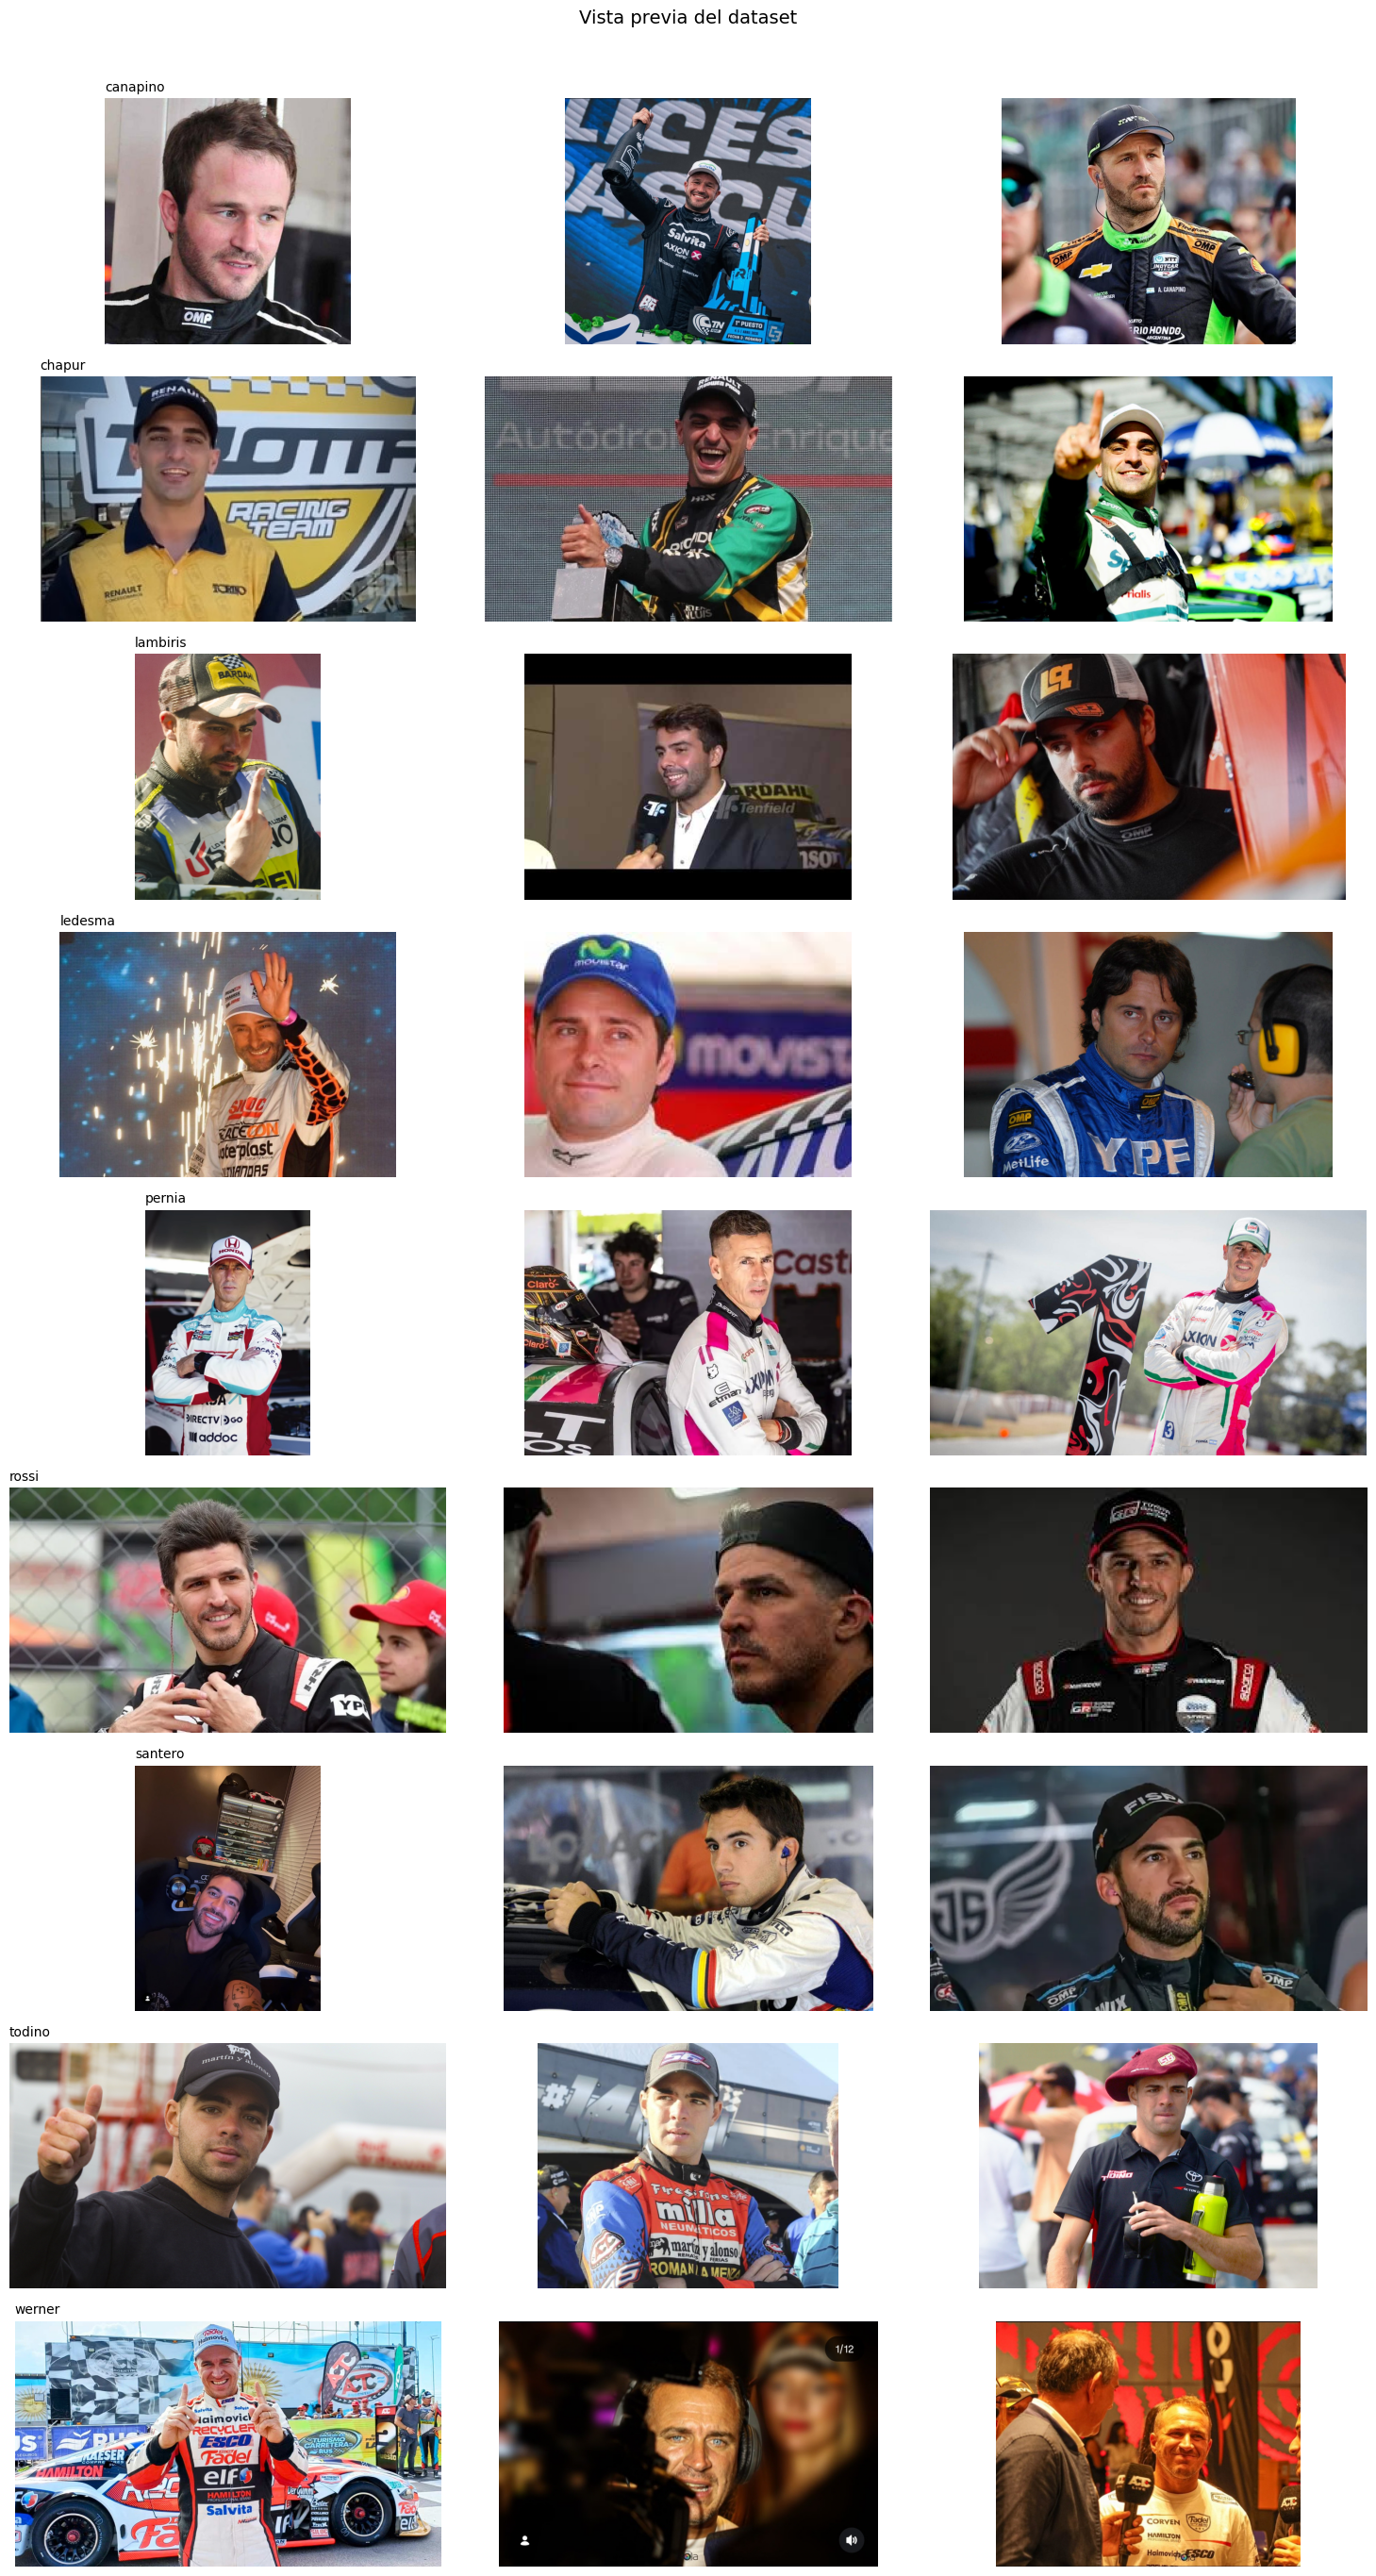

In [4]:
# Mostrar 3 fotos de cada persona para inspeccionar el dataset
n_personas = len(personas)
fig, axes = plt.subplots(n_personas, 3, figsize=(15, 3 * n_personas))


for i, persona in enumerate(personas):
    fotos = list((DATASET_PATH / persona).glob("*.jpg"))[:3]
    for j, foto in enumerate(fotos):
        img = Image.open(foto).convert('RGB')
        axes[i, j].imshow(img)
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_title(persona, fontsize=10, loc='left')

plt.suptitle("Vista previa del dataset", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 1. Deteccion y alineacion con MTCNN

d:\Respaldo\TUIA\Computer vision\tuia-face-recognition-app\.venv-notebook\Lib\site-packages\facenet_pytorch\models\mtcnn.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
 

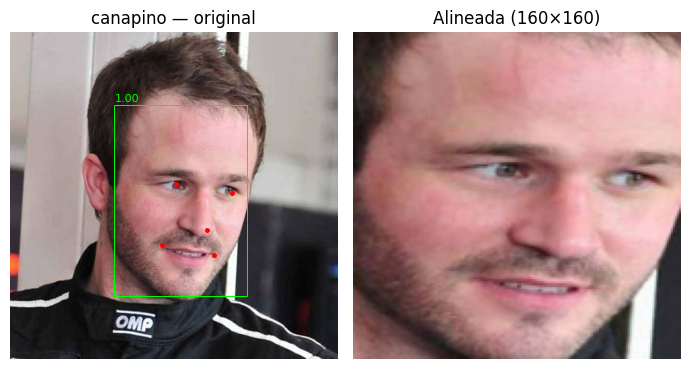

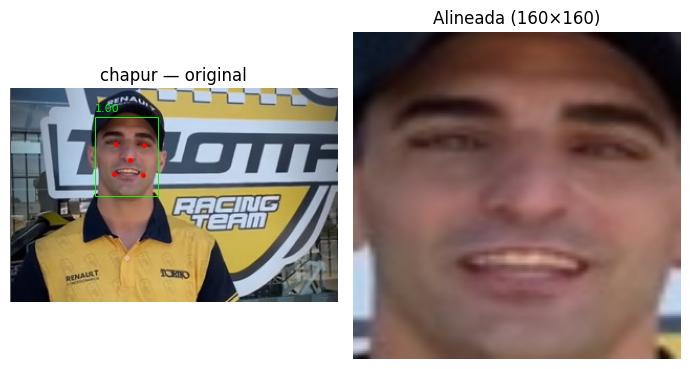

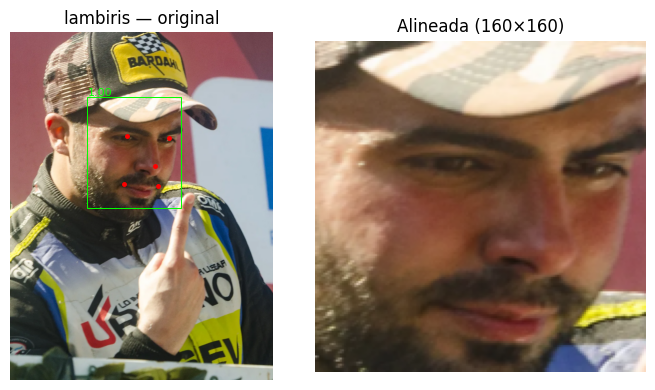

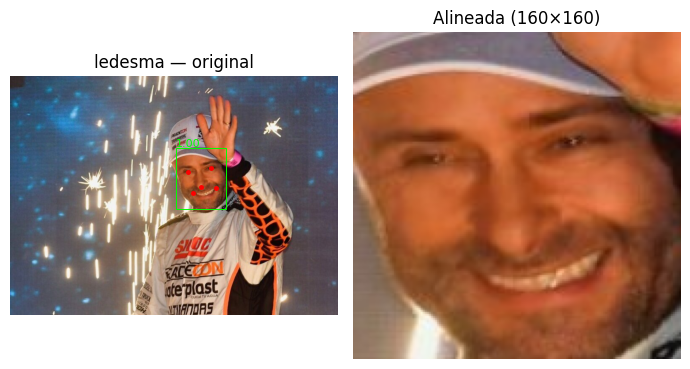

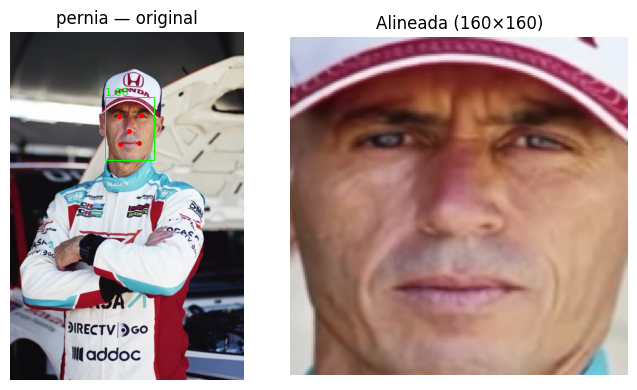

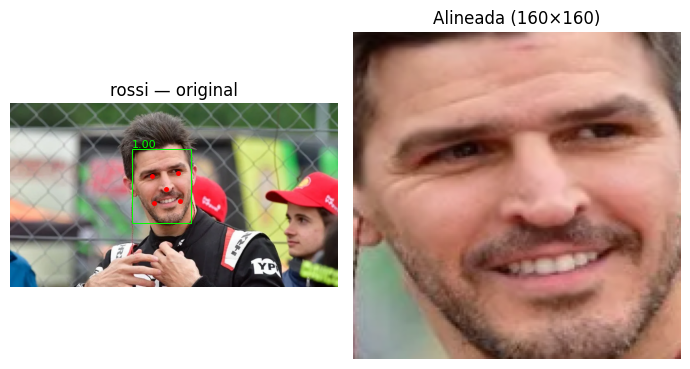

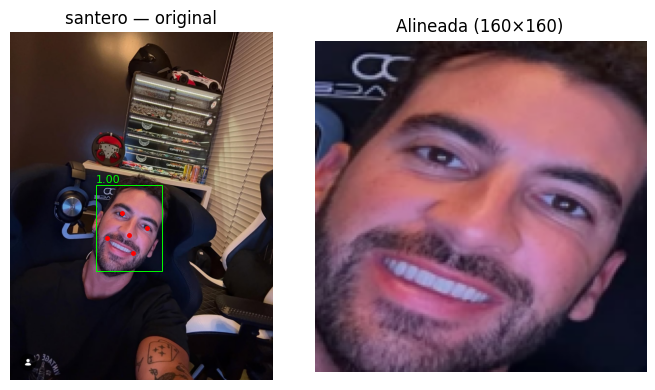

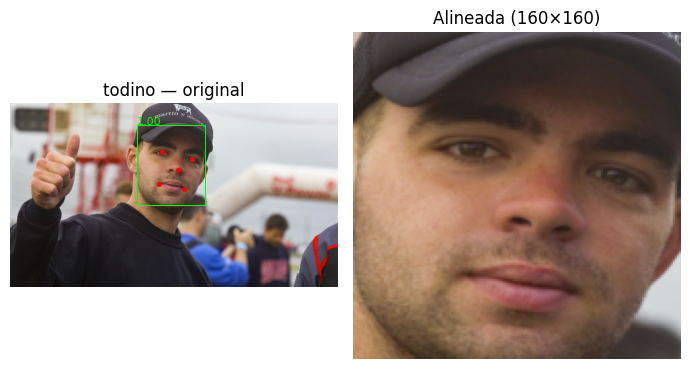

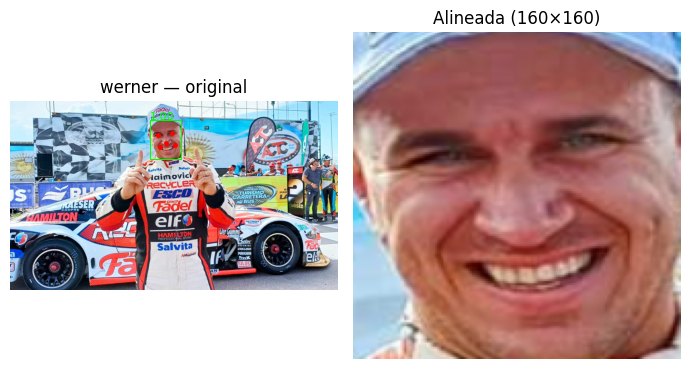


Procesamiento completo.
Sin cara detectada (0):


In [5]:
# image_size=160: InceptionResnetV1 espera imágenes de 160×160
# keep_all=False: en el dataset cada foto tiene una sola persona, nos quedamos con la más probable
mtcnn = MTCNN(image_size=160, keep_all=False, device=device)

OUTPUT_PATH = Path('src/data/dataset_recortado')  # donde se guardan las caras alineadas
no_detectadas = []

# seen evita mostrar la visualización más de una vez por persona
seen = set()
for persona in personas:
    # Crear subcarpeta de destino para cada persona
    target_dir = OUTPUT_PATH / persona
    target_dir.mkdir(parents=True, exist_ok=True)
    
    fotos = list((DATASET_PATH / persona).glob("*.jpg"))
    
    for foto_path in fotos:
        img = Image.open(foto_path).convert('RGB')
        boxes, probs, landmarks = mtcnn.detect(img, landmarks=True) # detect() devuelve boxes (N,4), probs (N,) y landmarks (N,5,2)

        face_tensor = mtcnn(img) # mtcnn(img) detecta, alinea usando landmarks y recorta a 160×160. Devuelve tensor (3, 160, 160) o None si no hay cara.
        
        #Guardar imagen recortada
        if face_tensor is not None:
            # Desnormalizar de [-1,1] a [0,255]: (tensor + 1) * 127.5
            # permute(1,2,0) cambia de (C,H,W) a (H,W,C) para PIL/numpy
            face_np = ((face_tensor.permute(1, 2, 0).numpy() + 1) * 127.5).clip(0, 255).astype(np.uint8)
            Image.fromarray(face_np).save(target_dir / foto_path.name)
        else:
            no_detectadas.append(f"{persona}/{foto_path.name}")
        
        # Visualización primera foto de cada persona
        if persona not in seen:
            seen.add(persona)
            fig, axes = plt.subplots(1, 2, figsize=(7, 4))
            
            axes[0].imshow(img)
            axes[0].set_title(f"{persona} — original")
            axes[0].axis("off")
            
            if boxes is not None:
                # Dibujar bounding box sobre la imagen original
                x1, y1, x2, y2 = boxes[0].astype(int)
                axes[0].add_patch(
                    patches.Rectangle(
                        (x1, y1), x2 - x1, y2 - y1,
                        linewidth=0.7, edgecolor="lime", facecolor="none"))
                
                axes[0].text(x1, y1 - 5, f"{probs[0]:.2f}", color="lime", fontsize=8)

                for kp in landmarks[0]:
                    axes[0].plot(kp[0], kp[1], "r.", markersize=5)
            
            if face_tensor is not None:
                axes[1].imshow(face_np)
                axes[1].set_title("Alineada (160×160)")
            else:
                axes[1].text(0.5, 0.5, "No detectada",
                             ha='center', va='center', transform=axes[1].transAxes,
                             fontsize=12, color='red')
                axes[1].set_title("Sin detección")
            axes[1].axis("off")
            
            plt.tight_layout()
            plt.show()

print(f"\nProcesamiento completo.")
print(f"Sin cara detectada ({len(no_detectadas)}):")
for f in no_detectadas:
    print(f"  {f}")

## 2. Modelo: InceptionResnetV1 / Generación de embeddings

FaceNet es una arquitectura diseñada específicamente para reconocimiento facial.
A diferencia de modelos de clasificación general FaceNet fue
entrenado con **Triplet Loss**: aprende a que la distancia entre embeddings de la
misma persona sea menor que la distancia entre personas distintas.

Usamos el modelo pre-entrenado en **VGGFace2**, lo que nos permite obtener embeddings de alta calidad con solo ~20 fotos propias por persona.

Primero generamos embeddings con el modelo base para analizar la separabilidad
del espacio vectorial antes de cualquier ajuste.


In [6]:
# Cargar InceptionResnetV1 pre-entrenado en VGGFace2
# .eval() pone el modelo en modo inferencia
modelo = InceptionResnetV1(pretrained='vggface2').eval().to(device)
print(f"InceptionResnetV1 cargado | Embedding: 512 dimensiones")
print(f"Parámetros: {sum(p.numel() for p in modelo.parameters()) / 1e6:.1f}M")


def get_embedding(img_path):
    """Genera el embedding de 512 dimensiones para una imagen 160x160 y cara alineada."""
    img = Image.open(img_path).convert("RGB")
    face = mtcnn(img)
    if face is None:
        return None
    # unsqueeze(0) agrega la dimensión de batch: (3,160,160) → (1,3,160,160), el modelo espera siempre un batch aunque sea de 1 sola imagen
    face = face.unsqueeze(0)
    with torch.no_grad():
        return modelo(face.to(device)).cpu().numpy()[0]


embeddings, emb_labels = [], []

for persona in personas:
    fotos = list((OUTPUT_PATH / persona).glob("*.jpg")) # imagenes ya recortadas y alineadas
    for foto_path in fotos:
        emb = get_embedding(foto_path)
        if emb is None:
            print(f"Sin cara: {persona}/{foto_path.name}")
            continue
        embeddings.append(emb)
        emb_labels.append(persona)  # etiqueta = nombre de la carpeta
        print(f"{persona}/{foto_path.name}  norma={np.linalg.norm(emb):.4f}")

embeddings = np.array(embeddings) # convierte la lista de vectores (512,) en matriz (N, 512)
print(f"\nEmbeddings: {embeddings.shape}")  # (n_fotos_total, 512)


d:\Respaldo\TUIA\Computer vision\tuia-face-recognition-app\.venv-notebook\Lib\site-packages\facenet_pytorch\models\inception_resnet_v1.py:329: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experime

InceptionResnetV1 cargado | Embedding: 512 dimensiones
Parámetros: 27.9M
canapino/foto1.jpg  norma=1.0000
canapino/foto10.jpg  norma=1.0000
canapino/foto11.jpg  norma=1.0000
canapino/foto12.jpg  norma=1.0000
canapino/foto13.jpg  norma=1.0000
canapino/foto14.jpg  norma=1.0000
canapino/foto15.jpg  norma=1.0000
canapino/foto16.jpg  norma=1.0000
canapino/foto17.jpg  norma=1.0000
canapino/foto2.jpg  norma=1.0000
canapino/foto3.jpg  norma=1.0000
canapino/foto4.jpg  norma=1.0000
canapino/foto5.jpg  norma=1.0000
canapino/foto6.jpg  norma=1.0000
canapino/foto7.jpg  norma=1.0000
canapino/foto8.jpg  norma=1.0000
canapino/foto9.jpg  norma=1.0000
chapur/foto1.jpg  norma=1.0000
chapur/foto10.jpg  norma=1.0000
chapur/foto11.jpg  norma=1.0000
chapur/foto12.jpg  norma=1.0000
chapur/foto13.jpg  norma=1.0000
chapur/foto14.jpg  norma=1.0000
chapur/foto15.jpg  norma=1.0000
chapur/foto16.jpg  norma=1.0000
chapur/foto17.jpg  norma=1.0000
chapur/foto2.jpg  norma=1.0000
chapur/foto3.jpg  norma=1.0000
chapur/fo

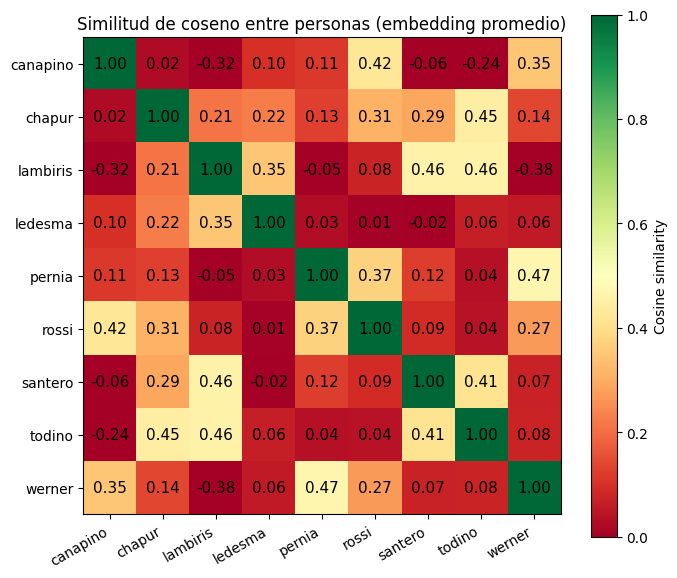

In [7]:
# Matriz de similitud de coseno entre personas (embedding promedio de n imagenes por clase en el dataset)

personas_unicas = sorted(set(emb_labels))
emb_promedio = {}

for persona in personas_unicas:
    # Indices de todas las fotos de esta persona
    indices = [i for i, l in enumerate(emb_labels) if l == persona]
    # Promedio de todos sus embeddings
    promedio = embeddings[indices].mean(axis=0)
    # Renormalizar a norma L2=1 después de promediar
    promedio = promedio / np.linalg.norm(promedio)
    emb_promedio[persona] = promedio

nombres = list(emb_promedio.keys())
galeria = np.array(list(emb_promedio.values()))  # matriz (n_personas, 512)

# Producto matricial: (n_personas, 512) @ (512, n_personas) = (n_personas, n_personas)
# Con embeddings L2-normalizados, el producto punto equivale a la similitud de coseno
sim_matrix = galeria @ galeria.T

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(sim_matrix, cmap="RdYlGn", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label="Cosine similarity")
ax.set_xticks(range(len(nombres)))
ax.set_yticks(range(len(nombres)))
ax.set_xticklabels(nombres, rotation=30, ha="right", fontsize=10)
ax.set_yticklabels(nombres, fontsize=10)
for i in range(len(nombres)):
    for j in range(len(nombres)):
        ax.text(j, i, f"{sim_matrix[i, j]:.2f}", ha="center", va="center", fontsize=11)
ax.set_title("Similitud de coseno entre personas (embedding promedio)")
plt.tight_layout()
plt.show()


In [8]:
## 3. Benchmark con LFW (Labeled Faces in the Wild)
# LFW es el dataset de referencia estándar para evaluar modelos de reconocimiento facial.
# Medimos Rank-1 Accuracy: para cada imagen de consulta.


# min_faces_per_person=70: solo personas con al menos 70 fotos
lfw = fetch_lfw_people(min_faces_per_person=70, resize=1.0, color=True)
X_raw, y_lfw, names = lfw.images, lfw.target, lfw.target_names
print(f"LFW: {X_raw.shape[0]} imágenes, {len(names)} personas: {list(names)}")

def preprocess_lfw(imgs):
    """Preprocesa imágenes LFW al formato que espera FaceNet.
    LFW viene en float [0,1] — lo convertimos a uint8 y luego aplicamos
    la misma normalización (pixel-127.5)/128.0 que usa MTCNN.
    """
    out = []
    for img in imgs:
        arr = (img * 255).astype(np.uint8)       # float [0,1] → uint8 [0,255]
        arr = cv2.resize(arr, (160, 160))         # redimensionar a 160×160
        arr = (arr.astype(np.float32) - 127.5) / 128.0  # normalizar como FaceNet
        out.append(arr.transpose(2, 0, 1))        # (H,W,C) → (C,H,W)
    return torch.tensor(np.array(out), dtype=torch.float32)

# Extraer embeddings en batches
lfw_embs = []
BATCH = 64
for i in range(0, len(X_raw), BATCH):
    batch = preprocess_lfw(X_raw[i:i+BATCH]).to(device)
    with torch.no_grad():
        lfw_embs.append(modelo(batch).cpu().numpy())

lfw_embs = np.vstack(lfw_embs)
print(f"Embeddings extraídos: {lfw_embs.shape}")

# Rank-1 Accuracy: dividir en galería (70%) y consultas (30%)
# Para cada consulta, buscar el embedding más similar en la galería y verificar si corresponde a la misma persona

X_gal, X_qry, y_gal, y_qry = train_test_split(
    lfw_embs, y_lfw, test_size=0.3, stratify=y_lfw, random_state=42)

# sims[i,j] = similitud entre consulta i y entrada j de la galería
sims = X_qry @ X_gal.T
# argmax da el índice del embedding más similar; y_gal[idx] da su etiqueta
preds = y_gal[sims.argmax(axis=1)]
accuracy = (preds == y_qry).mean()
print(f"Rank-1 Accuracy en LFW: {accuracy:.2%}")


LFW: 1288 imágenes, 7 personas: ['Ariel Sharon', 'Colin Powell', 'Donald Rumsfeld', 'George W Bush', 'Gerhard Schroeder', 'Hugo Chavez', 'Tony Blair']
Embeddings extraídos: (1288, 512)
Rank-1 Accuracy en LFW: 99.74%


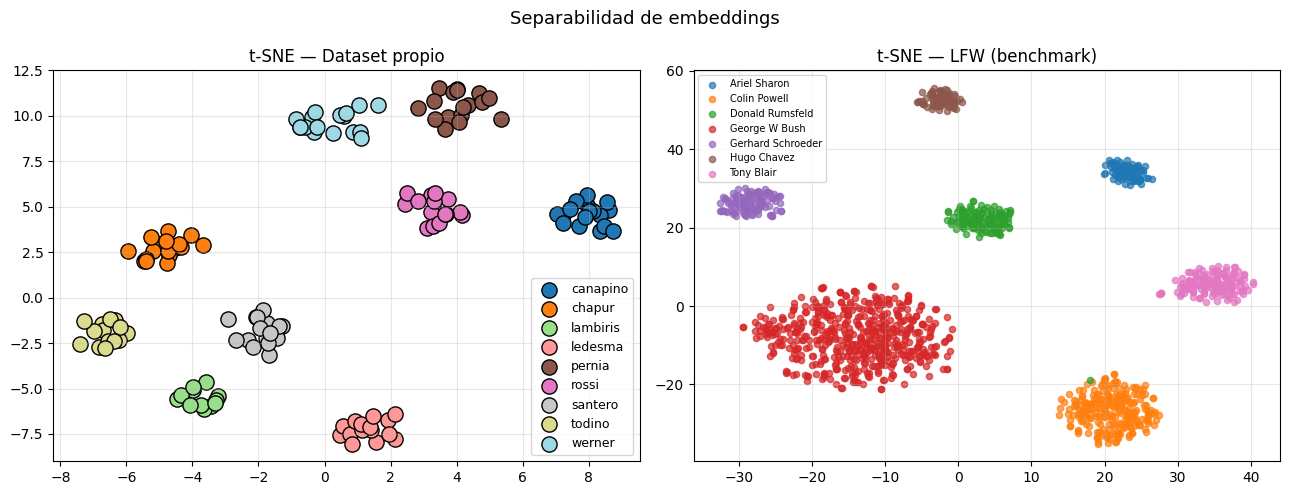

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Dataset propio
le = LabelEncoder()
# fit_transform convierte etiquetas string a índices numéricos: {canapino:0, chapur:1, ...}
y_own = le.fit_transform(emb_labels)

# perplexity debe ser menor que el número de muestras, controla el balance entre estructura local y global en la proyección
perp_own = min(30, len(embeddings) - 1)
tsne_own = TSNE(n_components=2, perplexity=perp_own, random_state=42)
# fit_transform reduce (N, 512) → (N, 2)
tsne2 = tsne_own.fit_transform(embeddings)
colors = plt.cm.tab20(np.linspace(0, 1, len(le.classes_)))

ax = axes[0]
for idx, cls in enumerate(le.classes_):
    mask = y_own == idx  # seleccionar solo los puntos de esta persona
    ax.scatter(tsne2[mask, 0], tsne2[mask, 1], label=cls, color=colors[idx], s=120, edgecolors="k")
ax.set_title("t-SNE — Dataset propio")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# LFW
perp_lfw = min(30, len(lfw_embs) - 1)
tsne_lfw = TSNE(n_components=2, perplexity=perp_lfw, random_state=42)
tsne_lfw2 = tsne_lfw.fit_transform(lfw_embs)

ax = axes[1]
for idx in range(len(names)):
    mask = y_lfw == idx
    ax.scatter(tsne_lfw2[mask, 0], tsne_lfw2[mask, 1], label=names[idx], s=20, alpha=0.7)
ax.set_title("t-SNE — LFW (benchmark)")
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

plt.suptitle("Separabilidad de embeddings", fontsize=13)
plt.tight_layout()
plt.show()


## 3. Fine-tuning — Dataset propio + LFW

Estrategia de fine-tuning:

Con solo ~20 fotos por persona, entrenar todo el modelo causaría overfitting.
La estrategia es congelar la mayor parte del backbone y ajustar solo las últimas capas:

- **Capas congeladas**: toda la red excepto `last_linear` y `last_bn` — ya aprendieron
  características faciales generales de 3.3M de imágenes
- **Capas entrenables**: `last_linear` y `last_bn` — se adaptan a nuestras personas
- **Head externo**: capa Linear(512 → N_clases) para clasificación, separada del backbone
  para que al exportar el modelo al backend solo guardemos el backbone sin el clasificador

Mezclar nuestras imágenes con un subconjunto balanceado de LFW evita el "catastrophic
forgetting" — el modelo recuerda cómo reconocer caras en general mientras aprende las nuestras.
Se usa la misma cantidad de imágenes LFW que propias por clase para mantener el balance.

**Función de pérdida**: CrossEntropyLoss — estándar para clasificación multiclase.

**Optimizador**: Adam con lr=1e-4 — learning rate bajo para no destruir pesos pre-entrenados.


In [10]:
# Cargar tensores del dataset propio
own_tensors, own_labels_raw = [], []

for persona in personas:
    fotos = list((OUTPUT_PATH / persona).glob("*.jpg"))
    for foto_path in fotos:
        face = mtcnn(Image.open(foto_path).convert("RGB")) # mtcnn() sobre una cara ya recortada aplica solo la normalización
        if face is None:
            continue
        own_tensors.append(face[0] if face.ndim == 4 else face)
        own_labels_raw.append(persona)

print(f"Dataset propio: {len(own_tensors)} imágenes | {len(set(own_labels_raw))} personas")

# Subconjunto de LFW balanceado
# Calcular cuántas imágenes LFW usar por clase para igualar al dataset propio
n_per_lfw = max(len(own_tensors) // len(set(own_labels_raw)), 3)
lfw_tensors, lfw_labels_raw = [], []
for cls_idx, cls_name in enumerate(names):

    idxs = np.where(y_lfw == cls_idx)[0][:n_per_lfw]
    for t in preprocess_lfw(X_raw[idxs]):
        lfw_tensors.append(t)
        lfw_labels_raw.append(cls_name)

print(f"LFW balanceado: {len(lfw_tensors)} imágenes | {len(set(lfw_labels_raw))} personas ({n_per_lfw} por clase)")

# Combinar datasets
all_tensors = own_tensors + lfw_tensors
all_labels_raw = own_labels_raw + lfw_labels_raw

# LabelEncoder convierte nombres de personas a índices numéricos
le_ft = LabelEncoder()
y_all = torch.tensor(le_ft.fit_transform(all_labels_raw), dtype=torch.long)

# torch.stack une la lista de tensores (3,160,160) en un tensor (N,3,160,160)
X_all = torch.stack(all_tensors)

# DataLoader maneja los mini-batches automáticamente, shuffle=True evita que el modelo vea siempre las mismas personas en el mismo orden
loader = DataLoader(TensorDataset(X_all, y_all), batch_size=8, shuffle=True)
print(f"\nFine-tuning: {len(all_tensors)} imágenes | {len(le_ft.classes_)} clases")

# Congelar todo el backbone 
for p in modelo.parameters():
    p.requires_grad = False

# Descongelar solo las dos capas finales del backbone
for p in modelo.last_linear.parameters():
    p.requires_grad = True
for p in modelo.last_bn.parameters():
    p.requires_grad = True

# Head externo: capa de clasificación separada del backbone
# Al exportar el modelo guardamos solo el backbone
# porque el backend identifica por similitud de coseno, no por clasificación
head = nn.Linear(512, len(le_ft.classes_)).to(device)

# Optimizar solo los parámetros entrenables (backbone parcial + head)
optimizer = torch.optim.Adam(
    list(modelo.last_linear.parameters()) +
    list(modelo.last_bn.parameters()) +
    list(head.parameters()),
    lr=1e-4  # learning rate bajo para no destruir pesos pre-entrenados
)
criterion = nn.CrossEntropyLoss()

#  Loop de entrenamiento
modelo.train()
for epoch in range(20):
    loss_sum, correct, total = 0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)  # mover batch a GPU
        emb = modelo(xb)          # backbone genera embedding (batch, 512)
        logits = head(emb)        # head clasifica: (batch, 512) → (batch, n_clases)
        loss = criterion(logits, yb)
        optimizer.zero_grad()     # limpiar gradientes del paso anterior
        loss.backward()           # calcular gradientes (backpropagation)
        optimizer.step()          # actualizar pesos con los gradientes
        loss_sum += loss.item()
        correct += (logits.argmax(1) == yb).sum().item()
        total += len(yb)
    print(f"Epoch {epoch+1:2d}  loss={loss_sum/len(loader):.4f}  acc={correct/total:.2%}")

# Volver a modo evaluación y reactivar todos los gradientes
modelo.eval()
for p in modelo.parameters():
    p.requires_grad = True

print("\nFine-tuning completado.")


Dataset propio: 142 imágenes | 9 personas
LFW balanceado: 105 imágenes | 7 personas (15 por clase)

Fine-tuning: 247 imágenes | 16 clases
Epoch  1  loss=2.7321  acc=34.82%
Epoch  2  loss=2.6560  acc=77.73%
Epoch  3  loss=2.5878  acc=90.28%
Epoch  4  loss=2.5236  acc=96.36%
Epoch  5  loss=2.4688  acc=95.95%
Epoch  6  loss=2.4185  acc=97.57%
Epoch  7  loss=2.3753  acc=99.19%
Epoch  8  loss=2.3446  acc=98.38%
Epoch  9  loss=2.3023  acc=98.38%
Epoch 10  loss=2.2740  acc=97.57%
Epoch 11  loss=2.2468  acc=99.60%
Epoch 12  loss=2.2094  acc=98.79%
Epoch 13  loss=2.1801  acc=97.98%
Epoch 14  loss=2.1593  acc=98.79%
Epoch 15  loss=2.1135  acc=99.19%
Epoch 16  loss=2.0883  acc=99.60%
Epoch 17  loss=2.0681  acc=100.00%
Epoch 18  loss=2.0438  acc=98.79%
Epoch 19  loss=2.0034  acc=99.60%
Epoch 20  loss=1.9957  acc=98.79%

Fine-tuning completado.


## 4. Guardar modelo

Guardamos el backbone completo como archivo `.pth`.
El backend solo necesita el backbone para generar embeddings,la identificación
se hace por similitud de coseno contra la galería, no con el head.


In [11]:
dst = Path("models")
dst.mkdir(parents=True, exist_ok=True)

model_path = dst / "inception_resnet_v1.pth"
torch.save(modelo, model_path)
print(f"Guardado en: {model_path} ({model_path.stat().st_size / 1e6:.1f} MB)")

# Verificar que el archivo se cargue y genere embeddings correctamente
loaded = torch.load(model_path, map_location="cpu", weights_only=False).eval()
with torch.no_grad():
    test = loaded(torch.randn(1, 3, 160, 160))
print(f"Carga OK - embedding: {test.shape} norma: {test.norm().item():.4f}")


Guardado en: models\inception_resnet_v1.pth (112.1 MB)
Carga OK - embedding: torch.Size([1, 512]) norma: 1.0000


## 5. Regenerar embeddings con el modelo guardado

Generamos los embeddings **cargando el modelo desde el archivo `.pth`** en lugar de usar
el objeto en memoria. Esto garantiza que los embeddings guardados en la base de datos
sean idénticos a los que generará el backend al recibir una imagen ya que ambos
usan el mismo archivo con el mismo modo de evaluación.

Si se usaran los embeddings del objeto en memoria podría haber discrepancias sutiles
por diferencias en el estado interno del modelo.

In [12]:
# Cargar desde el archivo .pth — mismo proceso que hace el backend al inicializarse
modelo_para_embeddings = torch.load(
    Path("models") / "inception_resnet_v1.pth",
    map_location=device,
    weights_only=False
).eval().to(device)

def get_embedding(img_path):
    """Genera embedding normalizado L2 usando el modelo del backend."""
    img = Image.open(img_path).convert("RGB")
    face = mtcnn(img)
    if face is None:
        return None
    face = face.unsqueeze(0).to(device)  # agregar dimensión batch
    with torch.no_grad():
        emb = modelo_para_embeddings(face).cpu().numpy()[0]
        emb = emb / (np.linalg.norm(emb) + 1e-8)
    return emb

embeddings, emb_labels = [], []

for persona in personas:
    fotos = list((OUTPUT_PATH / persona).glob("*.jpg"))
    for foto_path in fotos:
        emb = get_embedding(foto_path)
        if emb is None:
            print(f"Sin cara: {persona}/{foto_path.name}")
            continue
        embeddings.append(emb)
        emb_labels.append(persona)

embeddings = np.array(embeddings)
print(f"Embeddings regenerados con modelo del backend: {embeddings.shape}")


Embeddings regenerados con modelo del backend: (142, 512)


## 6. Cargar embeddings en PostgreSQL + pgvector

Poblamos la base de datos vectorial con los embeddings de todas las personas registradas.

**Requisito**: Docker debe estar corriendo (`docker compose up`) para que PostgreSQL esté disponible.
La conexión usa `localhost:5432` porque Docker expone ese puerto hacia la máquina local.


In [13]:
# Agregar src/ al path para poder importar los módulos del backend
sys.path.insert(0, str(Path("src")))


# Conectarse al PostgreSQL que corre dentro de Docker
# host=localhost porque Docker expone el puerto 5432 hacia la máquina local
pg = PgVectorEmbeddingStore(
    host="localhost",
    port=5432,
    dbname="faces",
    user="faces_user",
    password="faces_pass",
    embedding_dim=512,
)

# Limpiar registros previos para evitar duplicados al re-ejecutar el notebook
with pg.conn.cursor() as cur:
    cur.execute("DELETE FROM embeddings")
    pg.conn.commit()  # confirmar la transacción (sin esto el DELETE no se aplica)
print("Tabla limpiada")

# Insertar un EmbeddingRecord por cada imagen del dataset
# uuid4() genera un identificador único para cada registro
for emb, label in zip(embeddings, emb_labels):
    pg.append(EmbeddingRecord(
        id_imagen=str(uuid4()),
        embedding=emb.tolist(),  # convertir numpy array a lista de floats
        path="",
        etiqueta=label,          # nombre de la persona, lo que devuelve el sistema al predecir
        metadata={},
    ))

records = pg.all()
print(f"{len(records)} embeddings cargados en pgvector")
for r in records:
    print(f"  {r.etiqueta:20s}  id={r.id_imagen[:8]}...")


Tabla limpiada
142 embeddings cargados en pgvector
  canapino              id=9f0eb974...
  canapino              id=8a7cd6c8...
  canapino              id=f4aeb362...
  canapino              id=7099ad3b...
  canapino              id=d3ca98e8...
  canapino              id=83ab2255...
  canapino              id=0cf37c35...
  canapino              id=213ecf4d...
  canapino              id=27bae04d...
  canapino              id=af4d0f0d...
  canapino              id=c01bdcf7...
  canapino              id=3a819156...
  canapino              id=e565b5f5...
  canapino              id=1320a431...
  canapino              id=6b3b9516...
  canapino              id=5468a275...
  canapino              id=feb55df1...
  chapur                id=da5d12bd...
  chapur                id=16256cd4...
  chapur                id=64826227...
  chapur                id=13747294...
  chapur                id=7fc0071b...
  chapur                id=5e8cfc2a...
  chapur                id=4cac71de...
  chapur     